In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

student_name = "Gian Evangelista"
student_id = "2025-0295"

id_num = int(student_id[-3:])
color1 = f"#{(id_num*7)%256:02x}{(id_num*3)%256:02x}{(id_num*5)%256:02x}"
color2 = f"#{(id_num*2)%256:02x}{(id_num*9)%256:02x}{(id_num*4)%256:02x}"

dataset_path = r"C:\comprog\Lab7_DataVizualization_Evangelista\spotify_top_1000_tracks.csv"
df = pd.read_csv(dataset_path, encoding="utf-8")
df['track_name'] = df['track_name'].str.strip()
df['artist'] = df['artist'].str.strip()
df['album'] = df['album'].str.strip()
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year.fillna(0).astype(int)
df['year'] = df['release_year']
df['decade'] = (df['release_year'] // 10) * 10
df = df.drop_duplicates(subset=['track_name', 'artist'], keep='first')

print("✅ Ready!")

✅ Ready!


In [2]:
# ADVANCED TECHNIQUES 1
try:
    sns.barplot(x='category', y='value', data=df)
    plt.title('Bar Plot Example')
    plt.show()
except KeyError as e:
    print(f"Column not found: {e}")
except ValueError as e:
    print(f"Value error during plotting: {e}")
except Exception as e:
    print(f"Unexpected error: {e}")

Value error during plotting: Could not interpret value `category` for `x`. An entry with this name does not appear in `data`.


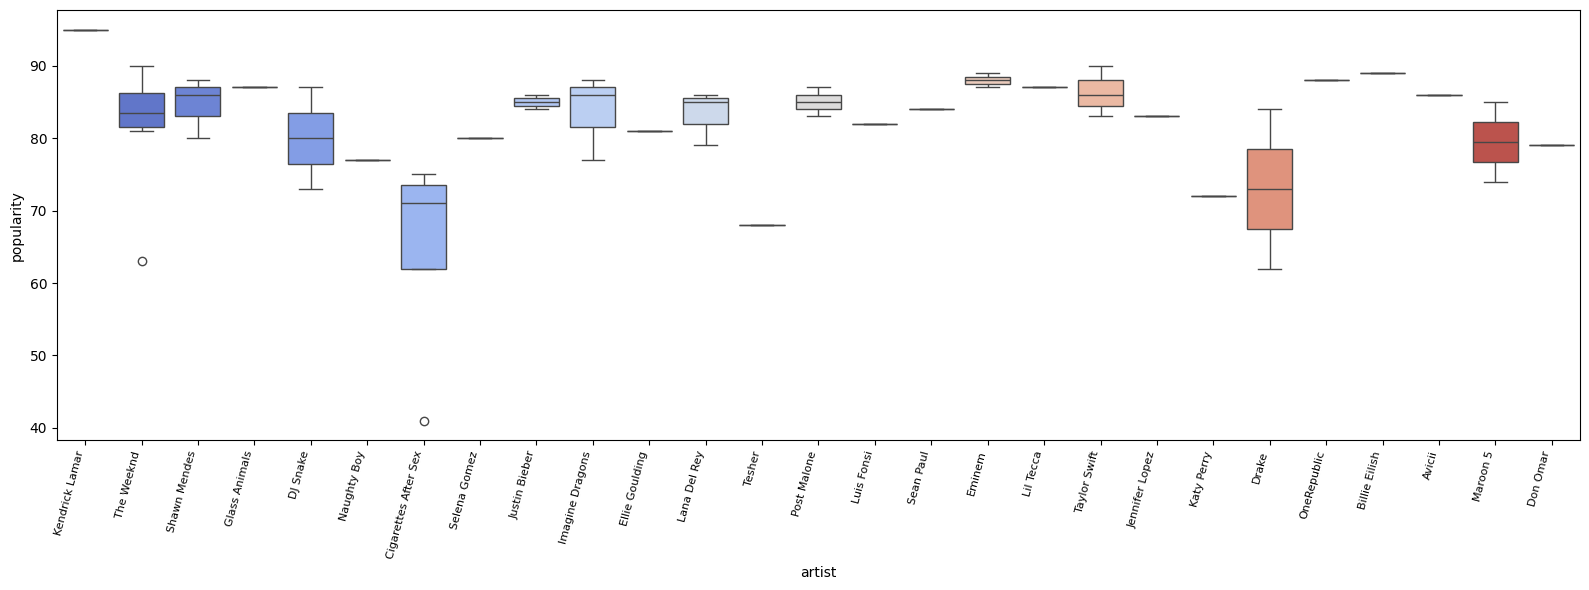

In [3]:
# ADVANCED TECHNIQUES 2
# Appendix B2 - Validate and Clean Data Before Plotting
if 'popularity' in df.columns and pd.api.types.is_numeric_dtype(df['popularity']):
    df_clean = df.dropna(subset=['artist', 'popularity'])
    plt.figure(figsize=(16, 6))
    sns.boxplot(x='artist', y='popularity', 
                data=df_clean.head(50),
                hue='artist', palette='coolwarm', legend=False)
    plt.xticks(rotation=75, ha='right', fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("Check column names or data types before plotting.")

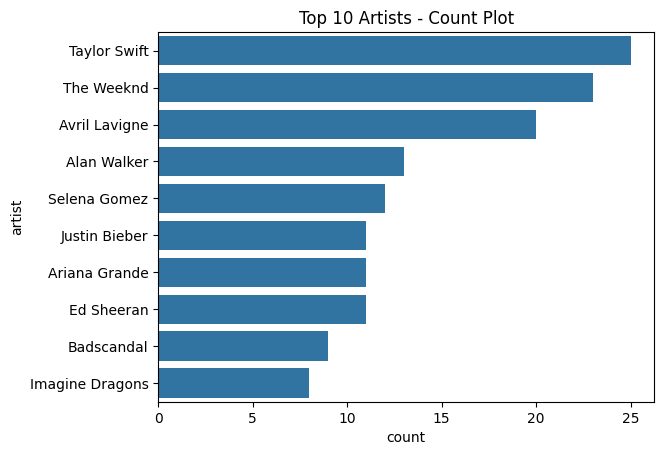

In [4]:
# ADVANCED TECHNIQUES 3
sns.countplot(y='artist', data=df, order=df['artist'].value_counts().head(10).index)
plt.title('Top 10 Artists - Count Plot')
plt.show()

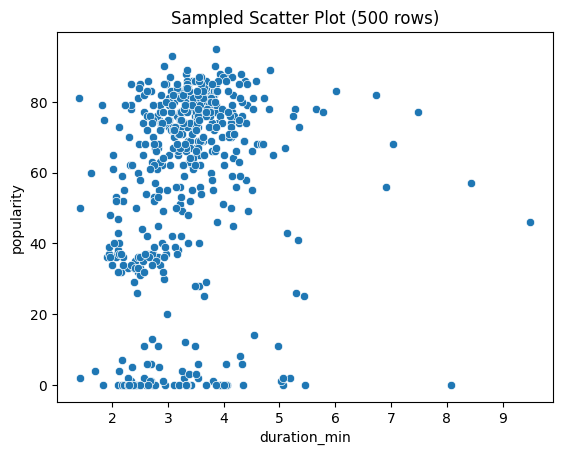

In [5]:
# ADVANCED TECHNIQUES 4
df_sample = df.sample(500)
sns.scatterplot(x='duration_min', y='popularity', data=df_sample)
plt.title('Sampled Scatter Plot (500 rows)')
plt.show()

C:\Users\gian\AppData\Local\Temp\ipykernel_12776\3233839263.py:3: UserWarning: 
The palette list has fewer values (5) than needed (6) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(x='decade', y='popularity', data=df_clean,


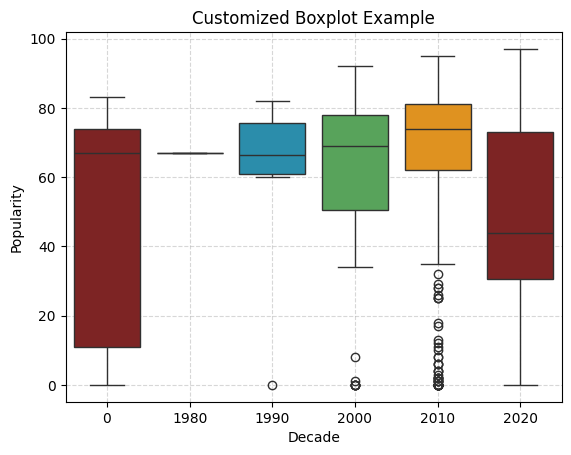

In [6]:
# ADVANCED TECHNIQUES 5
df_clean = df.dropna(subset=['artist', 'popularity'])
sns.boxplot(x='decade', y='popularity', data=df_clean,
            hue='decade', palette=['#8C1515','#888888','#1598C1','#4CAF50','#FF9800'],
            legend=False)
plt.title('Customized Boxplot Example')
plt.xlabel('Decade')
plt.ylabel('Popularity')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()